In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
from scipy.interpolate import interp1d
plt.style.use('default')

# --- 1. Settings and initialization ---
DATA_FILE = 'updated_combined_results.csv'
MODEL_NAME = 'exponential'
OUTPUT_BASE_FOLDER = f'variogram_model_fit_simple_{MODEL_NAME}'
INITIAL_BIN_INTERVAL = 0.5
RETRY_ATTEMPTS = 3
BIN_INTERVAL_MULTIPLIER = 2

os.makedirs(OUTPUT_BASE_FOLDER, exist_ok=True)
overall_summary = []

# Load data
try:
    data = pd.read_csv(DATA_FILE)
except FileNotFoundError:
    print(f"Error: Data file '{DATA_FILE}' not found. Please ensure the file exists.")
    exit()

# --- 2. Variogram analysis loop ---
for key, group_df in data.groupby('File Key_1'):
    print(f"\n--- Processing File Key: {key} ---")

    depth_values = group_df['Depth'].values
    values = group_df['withinres'].values

    if len(depth_values) < 10:
        print(f"  Skipping {key}: Not enough data points ({len(depth_values)} < 10).")
        continue

    coordinates = np.vstack([depth_values]).T
    maxlag = max(1, int((np.max(depth_values) - np.min(depth_values)) / 2))
    current_bin_interval = INITIAL_BIN_INTERVAL

    for attempt in range(RETRY_ATTEMPTS):
        try:
            n_lags = max(2, int(maxlag / current_bin_interval))
            V = Variogram(
                coordinates,
                values,
                model=MODEL_NAME,
                maxlag=maxlag,
                n_lags=n_lags,
                normalize=True,  # 순수 계산
                use_nugget=False,
                fit_method='trf',
                fit_sill=True,
                fit_range=True
            )

            # --- Extract data ---
            bins = V.bins
            semivars = V.experimental
            y_fit = V.fitted_model(bins)
            counts = V.bin_count

            # --- Visualize and save ---
            fig = V.plot(show=False)
            fig.suptitle(f'Variogram - {key} ({MODEL_NAME}, bin={current_bin_interval:.2f}m)')
            fig.savefig(os.path.join(OUTPUT_BASE_FOLDER, f'{key}_variogram_bin{current_bin_interval:.2f}m.png'))
            plt.close(fig)

            # Save experimental + fitted
            pd.DataFrame({
                'Lag (m)': bins,
                'Semivariance': semivars,
                'Count': counts,
                'Fitted_Semivariance': y_fit
            }).to_csv(os.path.join(OUTPUT_BASE_FOLDER, f'{key}_variogram_bin{current_bin_interval:.2f}m.csv'), index=False)

            # Interpolated fitted curve
            interp_func = interp1d(bins, y_fit, kind='linear', fill_value='extrapolate')
            lag_dense = np.arange(0, maxlag + 0.1, 0.02)
            fitted_dense = interp_func(lag_dense)
            fitted_dense = np.maximum(fitted_dense, 0)
            fitted_dense[lag_dense == 0] = 0

            pd.DataFrame({
                'Lag (m)': lag_dense,
                'Fitted_Semivariance': fitted_dense
            }).to_csv(os.path.join(OUTPUT_BASE_FOLDER, f'{key}_variogram_fitted_curve_bin{current_bin_interval:.2f}m.csv'), index=False)

            # --- Summarize parameters ---
            desc = V.describe()
            effective_range = desc.get('effective_range', np.nan)
            check_note = np.nan
            if not np.isnan(effective_range) and np.isclose(effective_range, maxlag):
                check_note = 'effective_range_eq_maxlag'

            overall_summary.append({
                'File Key_1': key,
                'nugget': desc.get('nugget', np.nan),
                'sill': desc.get('sill', np.nan),
                'effective_range': effective_range,
                'smoothness': desc.get('smoothness', np.nan),
                'maxlag': maxlag,
                'bin_interval_used': current_bin_interval,
                'Check': check_note
            })

            break  # 성공 시 반복 종료

        except Exception as e:
            print(f"  Failed attempt {attempt+1} for {key} with bin_interval {current_bin_interval:.2f}m: {e}")
            current_bin_interval *= BIN_INTERVAL_MULTIPLIER
            if attempt == RETRY_ATTEMPTS - 1:
                overall_summary.append({
                    'File Key_1': key,
                    'nugget': np.nan,
                    'sill': np.nan,
                    'effective_range': np.nan,
                    'smoothness': np.nan,
                    'maxlag': maxlag,
                    'bin_interval_used': current_bin_interval / BIN_INTERVAL_MULTIPLIER,
                    'Check': 'Failed'
                })

# --- Save final summary ---
pd.DataFrame(overall_summary).to_csv(
    os.path.join(OUTPUT_BASE_FOLDER, 'variogram_parameters_summary.csv'),
    index=False
)

print("\n--- Variogram analysis complete ---")
print(f"Results saved to the '{OUTPUT_BASE_FOLDER}' folder.")


ModuleNotFoundError: No module named 'skgstat'

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
from scipy.interpolate import interp1d

# --- WLS weighting option ---
# 'default': sigma = sqrt(h^2 / n)
# 'exp': sigma = 1 / sqrt(n * exp(-lag / c))
WLS_OPTION = 'exp'   # 선택: 'default' 또는 'exp'
C_DECAY = 5          # exp 가중치에서 c 값 (상관거리 감쇠 계수)

# --- 1. Settings and initialization ---
DATA_FILE = 'updated_combined_results.csv'
MODEL_NAME = 'exponential'
INITIAL_BIN_INTERVAL = 0.5
OUTPUT_BASE_FOLDER = f'variogram_model_fit_WLS_{MODEL_NAME}_{WLS_OPTION}_{INITIAL_BIN_INTERVAL}'

RETRY_ATTEMPTS = 3
BIN_INTERVAL_MULTIPLIER = 2

os.makedirs(OUTPUT_BASE_FOLDER, exist_ok=True)
overall_summary = []

# Load data
try:
    data = pd.read_csv(DATA_FILE)
except FileNotFoundError:
    print(f"Error: Data file '{DATA_FILE}' not found. Please ensure the file exists.")
    exit()

# --- 2. Variogram analysis loop ---
for key, group_df in data.groupby('File Key_1'):
    print(f"\n--- Processing File Key: {key} ---")

    depth_values = group_df['Depth'].values
    values = group_df['withinres'].values

    if len(depth_values) < 10:
        print(f"  Skipping {key}: Not enough data points ({len(depth_values)} < 10).")
        continue

    coordinates = np.vstack([depth_values]).T
    maxlag = max(1, int((np.max(depth_values) - np.min(depth_values)) / 2))
    current_bin_interval = INITIAL_BIN_INTERVAL

    for attempt in range(RETRY_ATTEMPTS):
        try:
            n_lags = max(2, int(maxlag / current_bin_interval))

            # --- 1. Preliminary variogram to get bin counts ---
            V_tmp = Variogram(
                coordinates,
                values,
                model=MODEL_NAME,
                maxlag=maxlag,
                n_lags=n_lags,
                normalize=True,
                fit_method=None
            )

            bins = V_tmp.bins
            counts = V_tmp.bin_count

            # --- 2. WLS sigma calculation ---
            counts_safe = np.where(counts == 0, np.nan, counts)
            bins_safe = np.where(bins == 0, np.nan, bins)

            if WLS_OPTION == 'default':
                sigma_vals = np.sqrt(bins_safe**2 / counts_safe)
            elif WLS_OPTION == 'exp':
                weights = counts_safe * np.exp(-bins_safe / C_DECAY)
                sigma_vals = 1 / np.sqrt(weights)
            else:
                raise ValueError(f"Unknown WLS_OPTION: {WLS_OPTION}")

            max_sigma = np.nanmax(sigma_vals[~np.isnan(sigma_vals)]) if np.any(~np.isnan(sigma_vals)) else 1.0
            sigma_vals = np.nan_to_num(sigma_vals, nan=max_sigma)
            min_range_bound = current_bin_interval
            max_range_bound = maxlag - current_bin_interval
            sill_min = 0.01
            sill_max = 10
            fit_bounds = ([min_range_bound, sill_min], [max_range_bound, sill_max])

            # --- 3. Final WLS variogram fitting ---
            V = Variogram(
                coordinates,
                values,
                model=MODEL_NAME,
                maxlag=maxlag,
                n_lags=n_lags,
                normalize=True,
                use_nugget=False,
                fit_method='trf',
                fit_sill=True,
                fit_range=True,
                fit_bounds=fit_bounds,
                fit_sigma=sigma_vals
            )

            # --- Extract data ---
            semivars = V.experimental
            y_fit = V.fitted_model(bins)
            counts = V.bin_count

            # --- Visualize and save ---
            fig = V.plot(show=True)
            fig.suptitle(f'Variogram - {key} ({MODEL_NAME} WLS-{WLS_OPTION}, bin={current_bin_interval:.2f}m)')
            fig.savefig(os.path.join(OUTPUT_BASE_FOLDER, f'{key}_variogram_WLS_{WLS_OPTION}_bin{current_bin_interval:.2f}m.png'))
            plt.close(fig)

            pd.DataFrame({
                'Lag (m)': bins,
                'Semivariance': semivars,
                'Count': counts,
                'Fitted_Semivariance': y_fit
            }).to_csv(os.path.join(OUTPUT_BASE_FOLDER, f'{key}_variogram_WLS_{WLS_OPTION}_bin{current_bin_interval:.2f}m.csv'), index=False)

            # Interpolated fitted curve
            interp_func = interp1d(bins, y_fit, kind='linear', fill_value='extrapolate')
            lag_dense = np.arange(0, maxlag + 0.1, 0.02)
            fitted_dense = interp_func(lag_dense)
            fitted_dense = np.maximum(fitted_dense, 0)
            fitted_dense[lag_dense == 0] = 0

            pd.DataFrame({
                'Lag (m)': lag_dense,
                'Fitted_Semivariance': fitted_dense
            }).to_csv(os.path.join(OUTPUT_BASE_FOLDER, f'{key}_variogram_fitted_curve_WLS_{WLS_OPTION}_bin{current_bin_interval:.2f}m.csv'), index=False)

            # --- Summarize parameters ---
            desc = V.describe()
            print(desc)
            effective_range = desc.get('effective_range', np.nan)
            check_note = np.nan
            if not np.isnan(effective_range) and np.isclose(effective_range, maxlag):
                check_note = 'effective_range_eq_maxlag'

            # --- Normalize by maximum experimental semivariance ---
            max_gamma = np.max(semivars)
            nugget_normalized = desc.get('nugget', np.nan) / max_gamma if max_gamma > 0 else np.nan
            sill_normalized = desc.get('sill', np.nan) / max_gamma if max_gamma > 0 else np.nan

            overall_summary.append({
                'File Key_1': key,
                'nugget': desc.get('nugget', np.nan),
                'sill': desc.get('sill', np.nan),
                'effective_range': effective_range,
                'smoothness': desc.get('smoothness', np.nan),
                'nugget_normalized': nugget_normalized,
                'sill_normalized': sill_normalized,
                'maxlag': maxlag,
                'bin_interval_used': current_bin_interval,
                'WLS_option': WLS_OPTION,
                'Check': check_note
            })

            break  # Exit loop on successful fit

        except Exception as e:
            print(f"  Failed attempt {attempt+1} for {key} with bin_interval {current_bin_interval:.2f}m: {e}")
            current_bin_interval *= BIN_INTERVAL_MULTIPLIER
            if attempt == RETRY_ATTEMPTS - 1:
                overall_summary.append({
                    'File Key_1': key,
                    'nugget': np.nan,
                    'sill': np.nan,
                    'effective_range': np.nan,
                    'smoothness': np.nan,
                    'nugget_normalized': np.nan,
                    'sill_normalized': np.nan,
                    'maxlag': maxlag,
                    'bin_interval_used': current_bin_interval / BIN_INTERVAL_MULTIPLIER,
                    'WLS_option': WLS_OPTION,
                    'Check': 'Failed'
                })

# --- Save final summary ---
pd.DataFrame(overall_summary).to_csv(
    os.path.join(OUTPUT_BASE_FOLDER, f'variogram_parameters_summary_WLS_{WLS_OPTION}.csv'),
    index=False
)

print("\n--- Variogram analysis complete ---")
print(f"Results saved to the '{OUTPUT_BASE_FOLDER}' folder with WLS option '{WLS_OPTION}'.")



--- Processing File Key: 14526 ---
{'model': 'exponential', 'estimator': 'matheron', 'dist_func': 'euclidean', 'normalized_effective_range': 26.546628713333714, 'normalized_sill': 0.0006617615103376681, 'normalized_nugget': 0, 'effective_range': 2.6546628713333713, 'sill': 0.022546097496267157, 'nugget': 0, 'params': {'estimator': 'matheron', 'model': 'exponential', 'dist_func': 'euclidean', 'bin_func': 'even', 'normalize': True, 'fit_method': 'trf', 'fit_sigma': array([0.0068227 , 0.00711637, 0.00758107, 0.00807796, 0.00861064,
       0.00918208, 0.00979553, 0.0104546 , 0.01116753, 0.01192692,
       0.01274968, 0.01363592, 0.01459272, 0.01562693, 0.01674945,
       0.0179631 , 0.01931812, 0.0207158 , 0.02227736, 0.02398245]), 'use_nugget': False, 'maxlag': 10, 'n_lags': 20, 'verbose': False}, 'kwargs': {'fit_sill': True, 'fit_range': True, 'fit_bounds': ([0.5, 0.01], [9.5, 10])}}

--- Processing File Key: 14539 ---
{'model': 'exponential', 'estimator': 'matheron', 'dist_func': 'eucl


--- Part 2 Finished ---
Total results: 10
Number of results removed: 0
Number of results plotted: 10


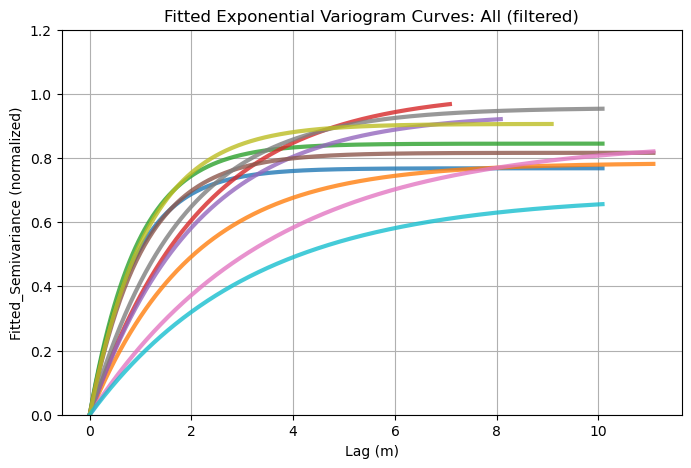

In [2]:
# -----------------------------------------------------------------------------
# Part 2: Load summary and plot fitted variogram curves from parameters
# -----------------------------------------------------------------------------

def exponential_variogram_func(h, nugget, sill, effective_range):
    """
    y = nugget + (sill - nugget) * (1 - exp(-h/a)), where a is the range parameter.
    This function now assumes normalized nugget and sill values.
    """
    partial_sill = sill - nugget

    # The range parameter 'a' is effective_range / 3 for the exponential model
    a = effective_range / 3

    if isinstance(h, (np.ndarray, list)):
        h = np.array(h)
        if np.isclose(a, 0):
            fitted_curve = np.full_like(h, sill)
        else:
            fitted_curve = nugget + partial_sill * (1 - np.exp(-h / a))

        fitted_curve[h == 0] = nugget

        return fitted_curve
    else:
        if np.isclose(h, 0):
            return nugget
        if np.isclose(a, 0):
            return sill
        return nugget + partial_sill * (1 - np.exp(-h / a))

# Use the correct summary file path from our previous conversation,
# which includes the 'Check' column.
SUMMARY_PATH = 'variogram_model_fit_WLS_exponential_exp_0.5/variogram_parameters_summary_WLS_exp.csv'

if not os.path.exists(SUMMARY_PATH):
    print(f"Error: The summary file '{SUMMARY_PATH}' was not found.")
else:
    summary = pd.read_csv(SUMMARY_PATH)

    if 'maxlag' not in summary.columns:
        print("Error: 'maxlag' column not found in the summary file. Please run the previous script to include it.")
        exit()

    # Check for 'sill_normalized' and 'nugget_normalized' columns
    if 'sill_normalized' not in summary.columns:
        print("Warning: 'sill_normalized' column not found. Calculating it now.")

        # This requires the original data to get the variance for normalization
        # We'll assume the variance is a good approximation of the sill if not normalized.
        # It's better to add the calculation to the first part of the script.
        # For now, we'll try to approximate it.
        # A more robust solution is to re-run the first script after adding 'var_val' to the summary.

        # As a temporary workaround, we'll just use the raw sill and nugget, and the plot won't be normalized.
        # We will add a note to the user.
        print("The plot will not be normalized as required data is missing. Please ensure the 'sill_normalized' and 'nugget_normalized' columns are in the summary file.")

        # Filter for valid models using the 'Check' column.
        valid_models = summary[summary['Check'].isna()]

        # Calculate counts
        removed = len(summary) - len(valid_models)
        kept = len(valid_models)
        total = len(summary)

        plt.figure(figsize=(8, 5))

        if not valid_models.empty:
            max_x_plot = max(valid_models['effective_range'].max() * 1.2, valid_models['maxlag'].max())
            if pd.isna(max_x_plot):
                max_x_plot = 50

            for index, row in valid_models.iterrows():
                nugget = row['nugget']
                sill = row['sill_normalized']
                effective_range = row['effective_range']
                maxlag_for_curve = row['maxlag']
                lag_dense_individual = np.arange(0, maxlag_for_curve + 0.1, 0.02)
                fitted_curve = [exponential_variogram_func(h, nugget, sill, effective_range) for h in lag_dense_individual]
                plt.plot(lag_dense_individual, fitted_curve, linewidth=3, alpha=0.8)

    else:
        # This is the correct path for a normalized plot
        valid_models = summary[summary['Check'].isna()]
        removed = len(summary) - len(valid_models)
        kept = len(valid_models)
        total = len(summary)

        plt.figure(figsize=(8, 5))

        if not valid_models.empty:
            max_x_plot = max(valid_models['effective_range'].max() * 1.2, valid_models['maxlag'].max())
            if pd.isna(max_x_plot):
                max_x_plot = 50

            for index, row in valid_models.iterrows():
                nugget = row['nugget_normalized'] if 'nugget_normalized' in row else 0 # Use 0 if not available
                sill = row['sill_normalized']
                effective_range = row['effective_range']
                maxlag_for_curve = row['maxlag']
                lag_dense_individual = np.arange(0, maxlag_for_curve + 0.1, 0.02)
                fitted_curve = [exponential_variogram_func(h, nugget, sill, effective_range) for h in lag_dense_individual]
                plt.plot(lag_dense_individual, fitted_curve, linewidth=3, alpha=0.8)

        plt.ylim(0, 1.2) # Set y-axis to be 0-1.2 for normalized view

    print(f"\n--- Part 2 Finished ---")
    print(f"Total results: {total}")
    print(f"Number of results removed: {removed}")
    print(f"Number of results plotted: {kept}")

    plt.xlabel('Lag (m)')
    plt.ylabel('Fitted_Semivariance (normalized)')
    plt.title('Fitted Exponential Variogram Curves: All (filtered)')
    plt.grid(True)
    plt.show()

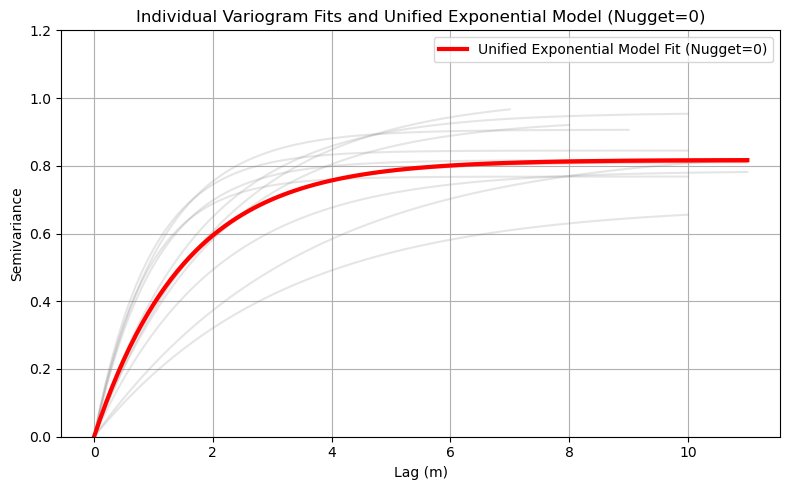


--- Part 2 Finished ---
Total results: 10
Number of results removed: 0
Number of results plotted: 10

Unified Exponential Model Parameters (Nugget fixed at 0):
  Nugget: 0.0000 (fixed)
  Sill  : 0.8174 ± 0.0055
  Range : 4.6126 ± 0.1357


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
from scipy.optimize import curve_fit

# -----------------------------------------------------------------------------
# Exponential variogram functions
# -----------------------------------------------------------------------------
def exponential_variogram_func(h, nugget, sill, effective_range):
    """
    Exponential variogram model with nugget parameter.
    y = nugget + (sill - nugget) * (1 - exp(-h / (effective_range/3)))
    """
    partial_sill = sill - nugget
    a = effective_range / 3

    h = np.array(h)
    if np.isclose(a, 0):
        fitted_curve = np.full_like(h, sill)
    else:
        fitted_curve = nugget + partial_sill * (1 - np.exp(-h / a))
    fitted_curve[h == 0] = nugget
    return fitted_curve

def exponential_variogram_func_fixed_nugget(h, sill, effective_range):
    """
    Exponential variogram with nugget fixed at 0.
    y = 0 + sill * (1 - exp(-h / (effective_range/3)))
    """
    a = effective_range / 3
    h = np.array(h)
    fitted_curve = sill * (1 - np.exp(-h / a))
    fitted_curve[h == 0] = 0.0
    return fitted_curve

# -----------------------------------------------------------------------------
# Part 2: Load summary and generate individual fitted curves
# -----------------------------------------------------------------------------
SUMMARY_PATH = 'variogram_model_fit_WLS_exponential_exp_0.5/variogram_parameters_summary_WLS_exp.csv'

if not os.path.exists(SUMMARY_PATH):
    print(f"Error: The summary file '{SUMMARY_PATH}' was not found.")
    exit()

summary = pd.read_csv(SUMMARY_PATH)
if 'maxlag' not in summary.columns:
    print("Error: 'maxlag' column not found in the summary file.")
    exit()

# Filter valid models (optional)
valid_summary = summary
removed = len(summary) - len(valid_summary)
kept = len(valid_summary)
total = len(summary)

nuggets = valid_summary['nugget'].values
sills = valid_summary['sill_normalized'].values
ranges = valid_summary['effective_range'].values
maxlags = valid_summary['maxlag'].values

if len(sills) == 0:
    print("No valid variogram models found to plot.")
    exit()

# --- Generate points from individual fitted curves ---
all_generated_lags = []
all_generated_semivariances = []

plt.figure(figsize=(8, 5))

for n, s, r, ml in zip(nuggets, sills, ranges, maxlags):
    lag_grid_individual = np.arange(0, ml + 0.1, 0.1)
    fitted_curve = exponential_variogram_func(lag_grid_individual, n, s, r)
    plt.plot(lag_grid_individual, fitted_curve, color='grey', alpha=0.2)
    all_generated_lags.extend(lag_grid_individual)
    all_generated_semivariances.extend(fitted_curve)

all_generated_lags = np.array(all_generated_lags)
all_generated_semivariances = np.array(all_generated_semivariances)

# -----------------------------------------------------------------------------
# Part 3: Unified curve fit with nugget fixed at 0
# -----------------------------------------------------------------------------
initial_guess = [np.mean(sills), np.mean(ranges)]
bounds_lower = [0.0, 0.0]
bounds_upper = [np.inf, np.inf]

try:
    popt_unified, pcov_unified = curve_fit(
        exponential_variogram_func_fixed_nugget,
        all_generated_lags,
        all_generated_semivariances,
        p0=initial_guess,
        bounds=(bounds_lower, bounds_upper)
    )
    unified_sill, unified_range = popt_unified
    perr_unified = np.sqrt(np.diag(pcov_unified))
    unified_sill_err, unified_range_err = perr_unified

except RuntimeError as e:
    print(f"Error: Unified curve fit failed. {e}")
    exit()

# Plot unified curve
max_lag_unified = np.max(maxlags)
lag_grid_dense = np.arange(0, max_lag_unified + 0.1, 0.1)
unified_curve = exponential_variogram_func_fixed_nugget(lag_grid_dense, unified_sill, unified_range)
plt.plot(lag_grid_dense, unified_curve, color='red', linewidth=3, label='Unified Exponential Model Fit (Nugget=0)')

# ±1 std dev shading
lower_bound_curve = exponential_variogram_func_fixed_nugget(
    lag_grid_dense,
    unified_sill - unified_sill_err,
    unified_range - unified_range_err
)
upper_bound_curve = exponential_variogram_func_fixed_nugget(
    lag_grid_dense,
    unified_sill + unified_sill_err,
    unified_range + unified_range_err
)
plt.fill_between(lag_grid_dense, lower_bound_curve, upper_bound_curve, color='red', alpha=0.3)

# Final plot adjustments
plt.xlabel('Lag (m)')
plt.ylabel('Semivariance')
plt.title('Individual Variogram Fits and Unified Exponential Model (Nugget=0)')
plt.grid(True)
plt.style.use('default')
plt.legend()
plt.ylim(0,1.2)
plt.tight_layout()
plt.savefig('unified_exponential_model_fit_nugget0.png')
plt.show()

# Print results
print("\n--- Part 2 Finished ---")
print(f"Total results: {total}")
print(f"Number of results removed: {removed}")
print(f"Number of results plotted: {kept}")
print("\nUnified Exponential Model Parameters (Nugget fixed at 0):")
print(f"  Nugget: 0.0000 (fixed)")
print(f"  Sill  : {unified_sill:.4f} ± {unified_sill_err:.4f}")
print(f"  Range : {unified_range:.4f} ± {unified_range_err:.4f}")
